# 02 — Data Quality Analysis

## Objective

This notebook performs full-data quality analysis of the training,
test, and ground-truth datasets.

The analysis focuses on:

- missing values
- empty and whitespace-only values
- identifier uniqueness
- duplicate identifiers
- exact duplicate records
- business-name quality
- address quality
- country quality
- cross-source consistency
- ground-truth structure

The objective is to identify data-quality characteristics that can
affect entity resolution and to establish evidence for the subsequent
normalization, candidate-generation, matching, and evaluation stages.

In [7]:
from pathlib import Path

import duckdb
import pandas as pd
import polars as pl
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

In [8]:
from pathlib import Path

CURRENT_DIR = Path.cwd()

DATA_DIR = CURRENT_DIR.parent / "dataset"
TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"

FILES = {
    "train_source1": TRAIN_DIR / "train_source1.tsv",
    "train_source2": TRAIN_DIR / "train_source2.tsv",
    "train_source3": TRAIN_DIR / "train_source3.tsv",
    "train_ground_truth": TRAIN_DIR / "train_ground_truth.tsv",
    "test_source1": TEST_DIR / "test_source1.tsv",
    "test_source2": TEST_DIR / "test_source2.tsv",
    "test_source3": TEST_DIR / "test_source3.tsv",
}

SOURCE_DATASETS = [
    "train_source1",
    "train_source2",
    "train_source3",
    "test_source1",
    "test_source2",
    "test_source3",
]

TRAIN_SOURCE_DATASETS = [
    "train_source1",
    "train_source2",
    "train_source3",
]

TEST_SOURCE_DATASETS = [
    "test_source1",
    "test_source2",
    "test_source3",
]

GROUND_TRUTH_DATASET = "train_ground_truth"

print("Current directory:")
print(CURRENT_DIR.resolve())

print("\nProject directory:")
print(CURRENT_DIR.parent.resolve())

print("\nData directory:")
print(DATA_DIR.resolve())

Current directory:
C:\Projects\amazon-ml-challenge-2026-main\student_resource\eda

Project directory:
C:\Projects\amazon-ml-challenge-2026-main\student_resource

Data directory:
C:\Projects\amazon-ml-challenge-2026-main\student_resource\dataset


In [9]:
for name, path in FILES.items():
    print(f"{name:20} -> {path}")
    print(f"exists = {path.exists()}")
    print()

train_source1        -> c:\Projects\amazon-ml-challenge-2026-main\student_resource\dataset\train\train_source1.tsv
exists = True

train_source2        -> c:\Projects\amazon-ml-challenge-2026-main\student_resource\dataset\train\train_source2.tsv
exists = True

train_source3        -> c:\Projects\amazon-ml-challenge-2026-main\student_resource\dataset\train\train_source3.tsv
exists = True

train_ground_truth   -> c:\Projects\amazon-ml-challenge-2026-main\student_resource\dataset\train\train_ground_truth.tsv
exists = True

test_source1         -> c:\Projects\amazon-ml-challenge-2026-main\student_resource\dataset\test\test_source1.tsv
exists = True

test_source2         -> c:\Projects\amazon-ml-challenge-2026-main\student_resource\dataset\test\test_source2.tsv
exists = True

test_source3         -> c:\Projects\amazon-ml-challenge-2026-main\student_resource\dataset\test\test_source3.tsv
exists = True



In [10]:
import duckdb
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

In [11]:
con = duckdb.connect()

print("DuckDB connection established.")

DuckDB connection established.


In [12]:
print("DATASET FILE CHECK")
print("=" * 80)

all_files_ok = True

for name, path in FILES.items():
    exists = path.exists()

    print(f"{name:20} | exists = {exists} | {path}")

    if not exists:
        all_files_ok = False

print("=" * 80)

if all_files_ok:
    print("All dataset files found successfully.")
else:
    print("WARNING: One or more dataset files are missing.")

DATASET FILE CHECK
train_source1        | exists = True | c:\Projects\amazon-ml-challenge-2026-main\student_resource\dataset\train\train_source1.tsv
train_source2        | exists = True | c:\Projects\amazon-ml-challenge-2026-main\student_resource\dataset\train\train_source2.tsv
train_source3        | exists = True | c:\Projects\amazon-ml-challenge-2026-main\student_resource\dataset\train\train_source3.tsv
train_ground_truth   | exists = True | c:\Projects\amazon-ml-challenge-2026-main\student_resource\dataset\train\train_ground_truth.tsv
test_source1         | exists = True | c:\Projects\amazon-ml-challenge-2026-main\student_resource\dataset\test\test_source1.tsv
test_source2         | exists = True | c:\Projects\amazon-ml-challenge-2026-main\student_resource\dataset\test\test_source2.tsv
test_source3         | exists = True | c:\Projects\amazon-ml-challenge-2026-main\student_resource\dataset\test\test_source3.tsv
All dataset files found successfully.


In [13]:
OUTPUT_DIR = CURRENT_DIR.parent / "eda_outputs"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory:", OUTPUT_DIR.resolve())
print("Table directory:", TABLE_DIR.resolve())
print("Figure directory:", FIGURE_DIR.resolve())

Output directory: C:\Projects\amazon-ml-challenge-2026-main\student_resource\eda_outputs
Table directory: C:\Projects\amazon-ml-challenge-2026-main\student_resource\eda_outputs\tables
Figure directory: C:\Projects\amazon-ml-challenge-2026-main\student_resource\eda_outputs\figures


In [14]:
row_count_results = []

for name, path in FILES.items():

    print(f"Counting rows: {name}")

    query = f"""
    SELECT COUNT(*) AS row_count
    FROM read_csv(
        '{path.as_posix()}',
        delim='\t',
        header=true,
        auto_detect=true
    )
    """

    row_count = con.execute(query).fetchone()[0]

    row_count_results.append({
        "dataset": name,
        "row_count": int(row_count)
    })

row_counts_df = pd.DataFrame(row_count_results)

display(row_counts_df)

Counting rows: train_source1
Counting rows: train_source2
Counting rows: train_source3
Counting rows: train_ground_truth
Counting rows: test_source1
Counting rows: test_source2
Counting rows: test_source3


,dataset,row_count
0,train_source1,2206821
1,train_source2,5034616
2,train_source3,5285603
3,train_ground_truth,2206821
4,test_source1,1732544
5,test_source2,4887273
6,test_source3,5082316


In [15]:
row_counts_df.to_csv(
    TABLE_DIR / "row_counts.csv",
    index=False
)

In [17]:
null_results = []

for name in SOURCE_DATASETS:

    path = FILES[name]

    print(f"Analyzing NULLs: {name}")

    query = f"""
    SELECT
        COUNT(*) AS total_rows,

        COUNT(*) - COUNT(entity_id)
            AS entity_id_nulls,

        COUNT(*) - COUNT(business_name)
            AS business_name_nulls,

        COUNT(*) - COUNT(business_address)
            AS business_address_nulls,

        COUNT(*) - COUNT(country)
            AS country_nulls

    FROM read_csv(
        '{path.as_posix()}',
        delim='\t',
        header=true,
        auto_detect=true
    )
    """

    result = con.execute(query).fetchone()

    total_rows = int(result[0])

    columns = [
        "entity_id",
        "business_name",
        "business_address",
        "country"
    ]

    for column, null_count in zip(columns, result[1:]):

        null_results.append({
            "dataset": name,
            "column": column,
            "total_rows": total_rows,
            "null_count": int(null_count),
            "null_percentage": round(
                100 * null_count / total_rows,
                4
            )
        })

null_summary_df = pd.DataFrame(null_results)

display(null_summary_df)

null_summary_df.to_csv(
    TABLE_DIR / "null_summary.csv",
    index=False
)

Analyzing NULLs: train_source1
Analyzing NULLs: train_source2
Analyzing NULLs: train_source3
Analyzing NULLs: test_source1
Analyzing NULLs: test_source2
Analyzing NULLs: test_source3


,dataset,column,total_rows,null_count,null_percentage
0,train_source1,entity_id,2206821,0,0.0000
1,train_source1,business_name,2206821,0,0.0000
2,train_source1,business_address,2206821,0,0.0000
3,train_source1,country,2206821,0,0.0000
4,train_source2,entity_id,5034616,0,0.0000
5,train_source2,business_name,5034616,0,0.0000
6,train_source2,business_address,5034616,168967,3.3561
7,train_source2,country,5034616,0,0.0000
8,train_source3,entity_id,5285603,0,0.0000
9,train_source3,business_name,5285603,0,0.0000


In [18]:
empty_results = []

for name in SOURCE_DATASETS:

    path = FILES[name]

    print(f"Analyzing empty values: {name}")

    query = f"""
    SELECT
        COUNT(*) AS total_rows,

        SUM(
            CASE
                WHEN entity_id IS NOT NULL
                 AND TRIM(entity_id) = ''
                THEN 1 ELSE 0
            END
        ) AS entity_id_empty,

        SUM(
            CASE
                WHEN business_name IS NOT NULL
                 AND TRIM(business_name) = ''
                THEN 1 ELSE 0
            END
        ) AS business_name_empty,

        SUM(
            CASE
                WHEN business_address IS NOT NULL
                 AND TRIM(business_address) = ''
                THEN 1 ELSE 0
            END
        ) AS business_address_empty,

        SUM(
            CASE
                WHEN country IS NOT NULL
                 AND TRIM(country) = ''
                THEN 1 ELSE 0
            END
        ) AS country_empty

    FROM read_csv(
        '{path.as_posix()}',
        delim='\t',
        header=true,
        auto_detect=true
    )
    """

    result = con.execute(query).fetchone()

    total_rows = int(result[0])

    columns = [
        "entity_id",
        "business_name",
        "business_address",
        "country"
    ]

    for column, empty_count in zip(columns, result[1:]):

        empty_results.append({
            "dataset": name,
            "column": column,
            "total_rows": total_rows,
            "empty_count": int(empty_count),
            "empty_percentage": round(
                100 * empty_count / total_rows,
                4
            )
        })

empty_summary_df = pd.DataFrame(empty_results)

display(empty_summary_df)

empty_summary_df.to_csv(
    TABLE_DIR / "empty_summary.csv",
    index=False
)

Analyzing empty values: train_source1
Analyzing empty values: train_source2
Analyzing empty values: train_source3
Analyzing empty values: test_source1
Analyzing empty values: test_source2
Analyzing empty values: test_source3


,dataset,column,total_rows,empty_count,empty_percentage
0,train_source1,entity_id,2206821,0,0.0
1,train_source1,business_name,2206821,0,0.0
2,train_source1,business_address,2206821,0,0.0
3,train_source1,country,2206821,0,0.0
4,train_source2,entity_id,5034616,0,0.0
5,train_source2,business_name,5034616,0,0.0
6,train_source2,business_address,5034616,0,0.0
7,train_source2,country,5034616,0,0.0
8,train_source3,entity_id,5285603,0,0.0
9,train_source3,business_name,5285603,0,0.0


In [19]:
combined_missing_df = null_summary_df.merge(
    empty_summary_df[
        [
            "dataset",
            "column",
            "empty_count",
            "empty_percentage"
        ]
    ],
    on=["dataset", "column"],
    how="left"
)

display(combined_missing_df)

combined_missing_df.to_csv(
    TABLE_DIR / "combined_missing_summary.csv",
    index=False
)

,dataset,column,total_rows,null_count,null_percentage,empty_count,empty_percentage
0,train_source1,entity_id,2206821,0,0.0000,0,0.0
1,train_source1,business_name,2206821,0,0.0000,0,0.0
2,train_source1,business_address,2206821,0,0.0000,0,0.0
3,train_source1,country,2206821,0,0.0000,0,0.0
4,train_source2,entity_id,5034616,0,0.0000,0,0.0
5,train_source2,business_name,5034616,0,0.0000,0,0.0
6,train_source2,business_address,5034616,168967,3.3561,0,0.0
7,train_source2,country,5034616,0,0.0000,0,0.0
8,train_source3,entity_id,5285603,0,0.0000,0,0.0
9,train_source3,business_name,5285603,0,0.0000,0,0.0


In [20]:
entity_id_results = []

for name in SOURCE_DATASETS:

    path = FILES[name]

    print(f"Checking entity_id uniqueness: {name}")

    query = f"""
    SELECT
        COUNT(*) AS total_rows,
        COUNT(entity_id) AS non_null_entity_ids,
        COUNT(DISTINCT entity_id) AS unique_entity_ids
    FROM read_csv(
        '{path.as_posix()}',
        delim='\t',
        header=true,
        auto_detect=true
    )
    """

    total_rows, non_null_ids, unique_ids = (
        con.execute(query).fetchone()
    )

    duplicate_rows = non_null_ids - unique_ids

    entity_id_results.append({
        "dataset": name,
        "total_rows": int(total_rows),
        "non_null_entity_ids": int(non_null_ids),
        "unique_entity_ids": int(unique_ids),
        "duplicate_entity_id_rows": int(duplicate_rows),
        "unique_percentage": round(
            100 * unique_ids / non_null_ids,
            4
        ) if non_null_ids else 0
    })

entity_id_summary_df = pd.DataFrame(entity_id_results)

display(entity_id_summary_df)
entity_id_summary_df.to_csv(
    TABLE_DIR / "entity_id_uniqueness.csv",
    index=False
)

Checking entity_id uniqueness: train_source1
Checking entity_id uniqueness: train_source2
Checking entity_id uniqueness: train_source3
Checking entity_id uniqueness: test_source1
Checking entity_id uniqueness: test_source2
Checking entity_id uniqueness: test_source3


,dataset,total_rows,non_null_entity_ids,unique_entity_ids,duplicate_entity_id_rows,unique_percentage
0,train_source1,2206821,2206821,2206821,0,100.0
1,train_source2,5034616,5034616,5034616,0,100.0
2,train_source3,5285603,5285603,5285603,0,100.0
3,test_source1,1732544,1732544,1732544,0,100.0
4,test_source2,4887273,4887273,4887273,0,100.0
5,test_source3,5082316,5082316,5082316,0,100.0


In [21]:
datasets_with_duplicate_ids = entity_id_summary_df[
    entity_id_summary_df["duplicate_entity_id_rows"] > 0
]["dataset"].tolist()

print("Datasets containing duplicate entity IDs:")
print()

if datasets_with_duplicate_ids:
    for name in datasets_with_duplicate_ids:
        print("-", name)
else:
    print("No duplicate entity IDs found.")

Datasets containing duplicate entity IDs:

No duplicate entity IDs found.


In [22]:
for name in datasets_with_duplicate_ids:

    path = FILES[name]

    print("\n" + "=" * 80)
    print(name)
    print("=" * 80)

    query = f"""
    SELECT
        entity_id,
        COUNT(*) AS occurrences
    FROM read_csv(
        '{path.as_posix()}',
        delim='\t',
        header=true,
        auto_detect=true
    )
    WHERE entity_id IS NOT NULL
    GROUP BY entity_id
    HAVING COUNT(*) > 1
    ORDER BY occurrences DESC
    LIMIT 100
    """

    duplicate_df = con.execute(query).fetchdf()

    display(duplicate_df)

In [24]:
exact_duplicate_results = []

for name in SOURCE_DATASETS:

    path = FILES[name]

    print(f"Checking exact duplicate records: {name}")

    query = f"""
    WITH grouped AS (
        SELECT
            entity_id,
            business_name,
            business_address,
            country,
            COUNT(*) AS occurrences
        FROM read_csv(
            '{path.as_posix()}',
            delim='\t',
            header=true,
            auto_detect=true
        )
        GROUP BY
            entity_id,
            business_name,
            business_address,
            country
    )

    SELECT
        COALESCE(
            SUM(occurrences - 1),
            0
        ) AS duplicate_rows
    FROM grouped
    WHERE occurrences > 1
    """

    duplicate_rows = con.execute(query).fetchone()[0]

    exact_duplicate_results.append({
        "dataset": name,
        "exact_duplicate_rows": int(duplicate_rows)
    })

exact_duplicate_df = pd.DataFrame(
    exact_duplicate_results
)

display(exact_duplicate_df)

exact_duplicate_df.to_csv(
    TABLE_DIR / "exact_duplicate_summary.csv",
    index=False
)

Checking exact duplicate records: train_source1
Checking exact duplicate records: train_source2
Checking exact duplicate records: train_source3
Checking exact duplicate records: test_source1
Checking exact duplicate records: test_source2
Checking exact duplicate records: test_source3


,dataset,exact_duplicate_rows
0,train_source1,0
1,train_source2,0
2,train_source3,0
3,test_source1,0
4,test_source2,0
5,test_source3,0


In [25]:
name_quality_results = []

for name in SOURCE_DATASETS:

    path = FILES[name]

    print(f"Analyzing business_name: {name}")

    query = f"""
    SELECT

        COUNT(*) AS total_rows,

        COUNT(business_name) AS non_null_names,

        SUM(
            CASE
                WHEN business_name IS NOT NULL
                 AND TRIM(business_name) = ''
                THEN 1 ELSE 0
            END
        ) AS empty_names,

        SUM(
            CASE
                WHEN business_name IS NOT NULL
                 AND LENGTH(TRIM(business_name)) <= 2
                THEN 1 ELSE 0
            END
        ) AS very_short_names,

        AVG(
            CASE
                WHEN business_name IS NOT NULL
                THEN LENGTH(TRIM(business_name))
            END
        ) AS mean_length,

        MEDIAN(
            CASE
                WHEN business_name IS NOT NULL
                THEN LENGTH(TRIM(business_name))
            END
        ) AS median_length,

        MAX(
            CASE
                WHEN business_name IS NOT NULL
                THEN LENGTH(TRIM(business_name))
            END
        ) AS max_length

    FROM read_csv(
        '{path.as_posix()}',
        delim='\t',
        header=true,
        auto_detect=true
    )
    """

    result = con.execute(query).fetchone()

    name_quality_results.append({
        "dataset": name,
        "total_rows": int(result[0]),
        "non_null_names": int(result[1]),
        "empty_names": int(result[2]),
        "very_short_names": int(result[3]),
        "mean_length": result[4],
        "median_length": result[5],
        "max_length": result[6]
    })

name_quality_df = pd.DataFrame(
    name_quality_results
)

display(name_quality_df)

name_quality_df.to_csv(
    TABLE_DIR / "business_name_quality.csv",
    index=False
)

Analyzing business_name: train_source1
Analyzing business_name: train_source2
Analyzing business_name: train_source3
Analyzing business_name: test_source1
Analyzing business_name: test_source2
Analyzing business_name: test_source3


,dataset,total_rows,non_null_names,empty_names,very_short_names,mean_length,median_length,max_length
0,train_source1,2206821,2206821,0,0,24.034403,24.0,105
1,train_source2,5034616,5034616,0,704,25.103575,25.0,104
2,train_source3,5285603,5285603,0,9275,25.202144,25.0,123
3,test_source1,1732544,1732544,0,0,23.836660,24.0,92
4,test_source2,4887273,4887273,0,10166,25.703646,25.0,102
5,test_source3,5082316,5082316,0,19910,25.655390,25.0,103


In [26]:
address_quality_results = []

for name in SOURCE_DATASETS:

    path = FILES[name]

    print(f"Analyzing business_address: {name}")

    query = f"""
    SELECT

        COUNT(*) AS total_rows,

        COUNT(business_address) AS non_null_addresses,

        SUM(
            CASE
                WHEN business_address IS NOT NULL
                 AND TRIM(business_address) = ''
                THEN 1 ELSE 0
            END
        ) AS empty_addresses,

        SUM(
            CASE
                WHEN business_address IS NOT NULL
                 AND LENGTH(TRIM(business_address)) <= 5
                THEN 1 ELSE 0
            END
        ) AS very_short_addresses,

        AVG(
            CASE
                WHEN business_address IS NOT NULL
                THEN LENGTH(TRIM(business_address))
            END
        ) AS mean_length,

        MEDIAN(
            CASE
                WHEN business_address IS NOT NULL
                THEN LENGTH(TRIM(business_address))
            END
        ) AS median_length,

        MAX(
            CASE
                WHEN business_address IS NOT NULL
                THEN LENGTH(TRIM(business_address))
            END
        ) AS max_length

    FROM read_csv(
        '{path.as_posix()}',
        delim='\t',
        header=true,
        auto_detect=true
    )
    """

    result = con.execute(query).fetchone()

    address_quality_results.append({
        "dataset": name,
        "total_rows": int(result[0]),
        "non_null_addresses": int(result[1]),
        "empty_addresses": int(result[2]),
        "very_short_addresses": int(result[3]),
        "mean_length": result[4],
        "median_length": result[5],
        "max_length": result[6]
    })

address_quality_df = pd.DataFrame(
    address_quality_results
)

display(address_quality_df)

address_quality_df.to_csv(
    TABLE_DIR / "business_address_quality.csv",
    index=False
)

Analyzing business_address: train_source1
Analyzing business_address: train_source2
Analyzing business_address: train_source3
Analyzing business_address: test_source1
Analyzing business_address: test_source2
Analyzing business_address: test_source3


,dataset,total_rows,non_null_addresses,empty_addresses,very_short_addresses,mean_length,median_length,max_length
0,train_source1,2206821,2206821,0,0,52.066219,41.0,256
1,train_source2,5034616,4865649,0,0,47.831177,37.0,249
2,train_source3,5285603,5109687,0,14,48.322719,42.0,240
3,test_source1,1732544,1732544,0,0,57.213184,50.0,268
4,test_source2,4887273,4757865,0,5,51.784587,43.0,269
5,test_source3,5082316,4946218,0,47,50.081597,44.0,267


In [27]:
country_quality_results = []

for name in SOURCE_DATASETS:

    path = FILES[name]

    print(f"Analyzing country: {name}")

    query = f"""
    SELECT

        COUNT(*) AS total_rows,

        COUNT(country) AS non_null_country,

        COUNT(DISTINCT country) AS distinct_country_values,

        SUM(
            CASE
                WHEN country IS NOT NULL
                 AND TRIM(country) = ''
                THEN 1 ELSE 0
            END
        ) AS empty_country

    FROM read_csv(
        '{path.as_posix()}',
        delim='\t',
        header=true,
        auto_detect=true
    )
    """

    result = con.execute(query).fetchone()

    country_quality_results.append({
        "dataset": name,
        "total_rows": int(result[0]),
        "non_null_country": int(result[1]),
        "distinct_country_values": int(result[2]),
        "empty_country": int(result[3])
    })

country_quality_df = pd.DataFrame(
    country_quality_results
)

display(country_quality_df)

country_quality_df.to_csv(
    TABLE_DIR / "country_quality.csv",
    index=False
)

Analyzing country: train_source1
Analyzing country: train_source2
Analyzing country: train_source3
Analyzing country: test_source1
Analyzing country: test_source2
Analyzing country: test_source3


,dataset,total_rows,non_null_country,distinct_country_values,empty_country
0,train_source1,2206821,2206821,2,0
1,train_source2,5034616,5034616,2,0
2,train_source3,5285603,5285603,2,0
3,test_source1,1732544,1732544,3,0
4,test_source2,4887273,4887273,3,0
5,test_source3,5082316,5082316,3,0


In [28]:
country_distribution = []

for name in SOURCE_DATASETS:

    path = FILES[name]

    query = f"""
    SELECT
        country,
        COUNT(*) AS row_count
    FROM read_csv(
        '{path.as_posix()}',
        delim='\t',
        header=true,
        auto_detect=true
    )
    GROUP BY country
    ORDER BY row_count DESC
    LIMIT 50
    """

    country_df = con.execute(query).fetchdf()

    country_df.insert(0, "dataset", name)

    country_distribution.append(country_df)

country_distribution_df = pd.concat(
    country_distribution,
    ignore_index=True
)

display(country_distribution_df)

country_distribution_df.to_csv(
    TABLE_DIR / "country_distribution.csv",
    index=False
)

,dataset,country,row_count
0,train_source1,US,1323633
1,train_source1,India,883188
2,train_source2,US,3016817
3,train_source2,India,2017799
4,train_source3,US,3170056
5,train_source3,India,2115547
6,test_source1,India,809986
7,test_source1,US,663106
8,test_source1,France,259452
9,test_source2,India,2312565


In [29]:
name_format_results = []

for name in SOURCE_DATASETS:

    path = FILES[name]

    query = f"""
    SELECT

        COUNT(*) AS total_rows,

        SUM(
            CASE
                WHEN business_name IS NOT NULL
                 AND REGEXP_MATCHES(
                     business_name,
                     '[0-9]'
                 )
                THEN 1 ELSE 0
            END
        ) AS names_with_digits,

        SUM(
            CASE
                WHEN business_name IS NOT NULL
                 AND REGEXP_MATCHES(
                     business_name,
                     '[^a-zA-Z0-9[:space:]]'
                 )
                THEN 1 ELSE 0
            END
        ) AS names_with_special_chars

    FROM read_csv(
        '{path.as_posix()}',
        delim='\t',
        header=true,
        auto_detect=true
    )
    """

    result = con.execute(query).fetchone()

    name_format_results.append({
        "dataset": name,
        "total_rows": int(result[0]),
        "names_with_digits": int(result[1]),
        "names_with_special_chars": int(result[2])
    })

name_format_df = pd.DataFrame(
    name_format_results
)

display(name_format_df)

name_format_df.to_csv(
    TABLE_DIR / "business_name_format_quality.csv",
    index=False
)

,dataset,total_rows,names_with_digits,names_with_special_chars
0,train_source1,2206821,35585,461669
1,train_source2,5034616,255636,2356371
2,train_source3,5285603,270847,2347044
3,test_source1,1732544,20207,351218
4,test_source2,4887273,190009,2277919
5,test_source3,5082316,202470,2205084


In [31]:
address_format_results = []

for name in SOURCE_DATASETS:

    path = FILES[name]

    query = f"""
    SELECT

        COUNT(*) AS total_rows,

        SUM(
            CASE
                WHEN business_address IS NOT NULL
                 AND REGEXP_MATCHES(
                     business_address,
                     '[0-9]'
                 )
                THEN 1 ELSE 0
            END
        ) AS addresses_with_digits,

        SUM(
            CASE
                WHEN business_address IS NOT NULL
                 AND REGEXP_MATCHES(
                     business_address,
                     '[^a-zA-Z0-9[:space:]]'
                 )
                THEN 1 ELSE 0
            END
        ) AS addresses_with_special_chars

    FROM read_csv(
        '{path.as_posix()}',
        delim='\t',
        header=true,
        auto_detect=true
    )
    """

    result = con.execute(query).fetchone()

    address_format_results.append({
        "dataset": name,
        "total_rows": int(result[0]),
        "addresses_with_digits": int(result[1]),
        "addresses_with_special_chars": int(result[2])
    })

address_format_df = pd.DataFrame(
    address_format_results
)

display(address_format_df)
address_format_df.to_csv(
    TABLE_DIR / "business_address_format_quality.csv",
    index=False
)

,dataset,total_rows,addresses_with_digits,addresses_with_special_chars
0,train_source1,2206821,2129784,2206821
1,train_source2,5034616,4563675,4865649
2,train_source3,5285603,4799297,5109686
3,test_source1,1732544,1660706,1732544
4,test_source2,4887273,4529243,4757687
5,test_source3,5082316,4700823,4946076


In [32]:
id_overlap_results = []

pairs = [
    ("train_source1", "train_source2"),
    ("train_source1", "train_source3"),
    ("train_source2", "train_source3"),
]

for left, right in pairs:

    print(f"Checking: {left} <-> {right}")

    query = f"""
    WITH left_ids AS (
        SELECT DISTINCT entity_id
        FROM read_csv(
            '{FILES[left].as_posix()}',
            delim='\t',
            header=true,
            auto_detect=true
        )
        WHERE entity_id IS NOT NULL
    ),

    right_ids AS (
        SELECT DISTINCT entity_id
        FROM read_csv(
            '{FILES[right].as_posix()}',
            delim='\t',
            header=true,
            auto_detect=true
        )
        WHERE entity_id IS NOT NULL
    )

    SELECT COUNT(*)
    FROM left_ids
    INNER JOIN right_ids
    USING (entity_id)
    """

    overlap = con.execute(query).fetchone()[0]

    id_overlap_results.append({
        "left_dataset": left,
        "right_dataset": right,
        "overlapping_entity_ids": int(overlap)
    })

id_overlap_df = pd.DataFrame(id_overlap_results)

display(id_overlap_df)
id_overlap_df.to_csv(
    TABLE_DIR / "cross_source_entity_id_overlap.csv",
    index=False
)

Checking: train_source1 <-> train_source2
Checking: train_source1 <-> train_source3
Checking: train_source2 <-> train_source3


,left_dataset,right_dataset,overlapping_entity_ids
0,train_source1,train_source2,0
1,train_source1,train_source3,0
2,train_source2,train_source3,0


In [33]:
gt_path = FILES[GROUND_TRUTH_DATASET]

query = f"""
SELECT
    COUNT(*) AS total_rows,
    COUNT(source1_entity_id) AS non_null_source1_entity_ids,
    COUNT(matched_entity_ids) AS non_null_matched_entity_ids,
    COUNT(DISTINCT source1_entity_id) AS unique_source1_entity_ids
FROM read_csv(
    '{gt_path.as_posix()}',
    delim='\t',
    header=true,
    auto_detect=true
)
"""

ground_truth_summary_df = con.execute(query).fetchdf()

display(ground_truth_summary_df)
ground_truth_summary_df.to_csv(
    TABLE_DIR / "ground_truth_summary.csv",
    index=False
)

,total_rows,non_null_source1_entity_ids,non_null_matched_entity_ids,unique_source1_entity_ids
0,2206821,2206821,2083574,2206821


In [35]:
query = f"""
SELECT

    SUM(
        CASE
            WHEN source1_entity_id IS NULL
            THEN 1 ELSE 0
        END
    ) AS source1_entity_id_nulls,

    SUM(
        CASE
            WHEN matched_entity_ids IS NULL
            THEN 1 ELSE 0
        END
    ) AS matched_entity_ids_nulls,

    SUM(
        CASE
            WHEN source1_entity_id IS NOT NULL
             AND TRIM(source1_entity_id) = ''
            THEN 1 ELSE 0
        END
    ) AS source1_entity_id_empty,

    SUM(
        CASE
            WHEN matched_entity_ids IS NOT NULL
             AND TRIM(matched_entity_ids) = ''
            THEN 1 ELSE 0
        END
    ) AS matched_entity_ids_empty

FROM read_csv(
    '{gt_path.as_posix()}',
    delim='\t',
    header=true,
    auto_detect=true
)
"""

ground_truth_quality_df = con.execute(query).fetchdf()

display(ground_truth_quality_df)
ground_truth_quality_df.to_csv(
    TABLE_DIR / "ground_truth_quality.csv",
    index=False
)

,source1_entity_id_nulls,matched_entity_ids_nulls,source1_entity_id_empty,matched_entity_ids_empty
0,0.0,123247.0,0.0,0.0


In [36]:
query = f"""
SELECT *
FROM read_csv(
    '{gt_path.as_posix()}',
    delim='\t',
    header=true,
    auto_detect=true
)
LIMIT 30
"""

ground_truth_sample_df = con.execute(query).fetchdf()

display(ground_truth_sample_df)

,source1_entity_id,matched_entity_ids
0,S1-965667,"S2-681193310,S2-743505751,S3-775321672,S3-1129..."
1,S1-55344266,"S2-249013014,S2-197070651,S3-478195123,S3-3843..."
2,S1-343815751,"S2-790675320,S2-479876582,S3-878454467"
3,S1-656753428,"S2-153058913,S2-24659151,S3-679606215"
4,S1-102811957,"S2-478959098,S2-553508714,S2-625774905,S3-7280..."
5,S1-18727616,"S2-755677256,S3-187831601,S3-641489370,S3-4762..."
6,S1-318373630,"S2-660036492,S3-804600254"
7,S1-86989137,"S3-274817120,S3-312496301"
8,S1-29845983,"S2-648035184,S3-588502663"
9,S1-789009573,"S2-383871912,S3-74481402,S3-576451439"


In [37]:
query = f"""
SELECT
    COUNT(*) AS total_rows,

    SUM(
        CASE
            WHEN matched_entity_ids LIKE '%,%'
            THEN 1 ELSE 0
        END
    ) AS rows_with_comma,

    SUM(
        CASE
            WHEN matched_entity_ids LIKE '%|%'
            THEN 1 ELSE 0
        END
    ) AS rows_with_pipe,

    SUM(
        CASE
            WHEN matched_entity_ids LIKE '%;%'
            THEN 1 ELSE 0
        END
    ) AS rows_with_semicolon,

    SUM(
        CASE
            WHEN matched_entity_ids LIKE '% %'
            THEN 1 ELSE 0
        END
    ) AS rows_with_space

FROM read_csv(
    '{gt_path.as_posix()}',
    delim='\t',
    header=true,
    auto_detect=true
)
"""

separator_check_df = con.execute(query).fetchdf()

display(separator_check_df)

,total_rows,rows_with_comma,rows_with_pipe,rows_with_semicolon,rows_with_space
0,2206821,1964417.0,0.0,0.0,0.0


In [39]:
query = f"""
WITH source1 AS (

    SELECT DISTINCT entity_id

    FROM read_csv(
        '{FILES["train_source1"].as_posix()}',
        delim='\t',
        header=true,
        auto_detect=true
    )

    WHERE entity_id IS NOT NULL
),

ground_truth AS (

    SELECT DISTINCT source1_entity_id

    FROM read_csv(
        '{gt_path.as_posix()}',
        delim='\t',
        header=true,
        auto_detect=true
    )

    WHERE source1_entity_id IS NOT NULL
)

SELECT

    COUNT(*) AS ground_truth_unique_ids,

    COUNT(source1.entity_id) AS ids_found_in_source1,

    COUNT(*) - COUNT(source1.entity_id)
        AS ids_missing_from_source1

FROM ground_truth

LEFT JOIN source1
    ON ground_truth.source1_entity_id = source1.entity_id
"""

gt_source1_validation_df = con.execute(query).fetchdf()

display(gt_source1_validation_df)
gt_source1_validation_df.to_csv(
    TABLE_DIR / "ground_truth_source1_validation.csv",
    index=False
)

,ground_truth_unique_ids,ids_found_in_source1,ids_missing_from_source1
0,2206821,2206821,0


In [40]:
query = f"""
SELECT
    source1_entity_id,
    COUNT(*) AS occurrences
FROM read_csv(
    '{gt_path.as_posix()}',
    delim='\t',
    header=true,
    auto_detect=true
)
WHERE source1_entity_id IS NOT NULL
GROUP BY source1_entity_id
HAVING COUNT(*) > 1
ORDER BY occurrences DESC
LIMIT 100
"""

gt_duplicate_source1_df = con.execute(query).fetchdf()

display(gt_duplicate_source1_df)

,source1_entity_id,occurrences


In [42]:
master_quality_rows = []

for name in SOURCE_DATASETS:

    row = {
        "dataset": name
    }

    row_count = row_counts_df.loc[
        row_counts_df["dataset"] == name,
        "row_count"
    ].iloc[0]

    row["total_rows"] = int(row_count)

    for column in [
        "entity_id",
        "business_name",
        "business_address",
        "country"
    ]:

        null_value = null_summary_df.loc[
            (null_summary_df["dataset"] == name) &
            (null_summary_df["column"] == column),
            "null_percentage"
        ].iloc[0]

        empty_value = empty_summary_df.loc[
            (empty_summary_df["dataset"] == name) &
            (empty_summary_df["column"] == column),
            "empty_percentage"
        ].iloc[0]

        row[f"{column}_null_pct"] = null_value
        row[f"{column}_empty_pct"] = empty_value

    duplicate_id_value = entity_id_summary_df.loc[
        entity_id_summary_df["dataset"] == name,
        "duplicate_entity_id_rows"
    ].iloc[0]

    row["duplicate_entity_id_rows"] = duplicate_id_value

    exact_duplicate_value = exact_duplicate_df.loc[
        exact_duplicate_df["dataset"] == name,
        "exact_duplicate_rows"
    ].iloc[0]

    row["exact_duplicate_rows"] = exact_duplicate_value

    master_quality_rows.append(row)

master_quality_df = pd.DataFrame(
    master_quality_rows
)

display(master_quality_df)
master_quality_df.to_csv(
    TABLE_DIR / "master_data_quality_summary.csv",
    index=False
)

,dataset,total_rows,entity_id_null_pct,entity_id_empty_pct,business_name_null_pct,business_name_empty_pct,business_address_null_pct,business_address_empty_pct,country_null_pct,country_empty_pct,duplicate_entity_id_rows,exact_duplicate_rows
0,train_source1,2206821,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,0.0,0,0
1,train_source2,5034616,0.0,0.0,0.0,0.0,3.3561,0.0,0.0,0.0,0,0
2,train_source3,5285603,0.0,0.0,0.0,0.0,3.3282,0.0,0.0,0.0,0,0
3,test_source1,1732544,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,0.0,0,0
4,test_source2,4887273,0.0,0.0,0.0,0.0,2.6479,0.0,0.0,0.0,0,0
5,test_source3,5082316,0.0,0.0,0.0,0.0,2.6779,0.0,0.0,0.0,0,0


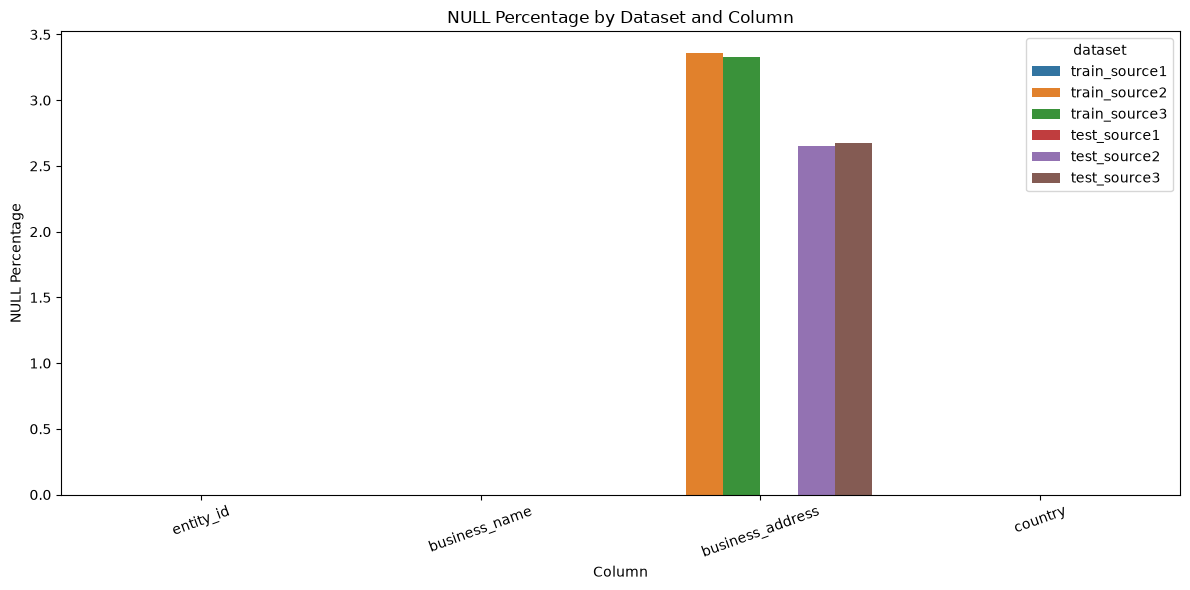

In [43]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=null_summary_df,
    x="column",
    y="null_percentage",
    hue="dataset"
)

plt.title("NULL Percentage by Dataset and Column")
plt.xlabel("Column")
plt.ylabel("NULL Percentage")

plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "null_percentage.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

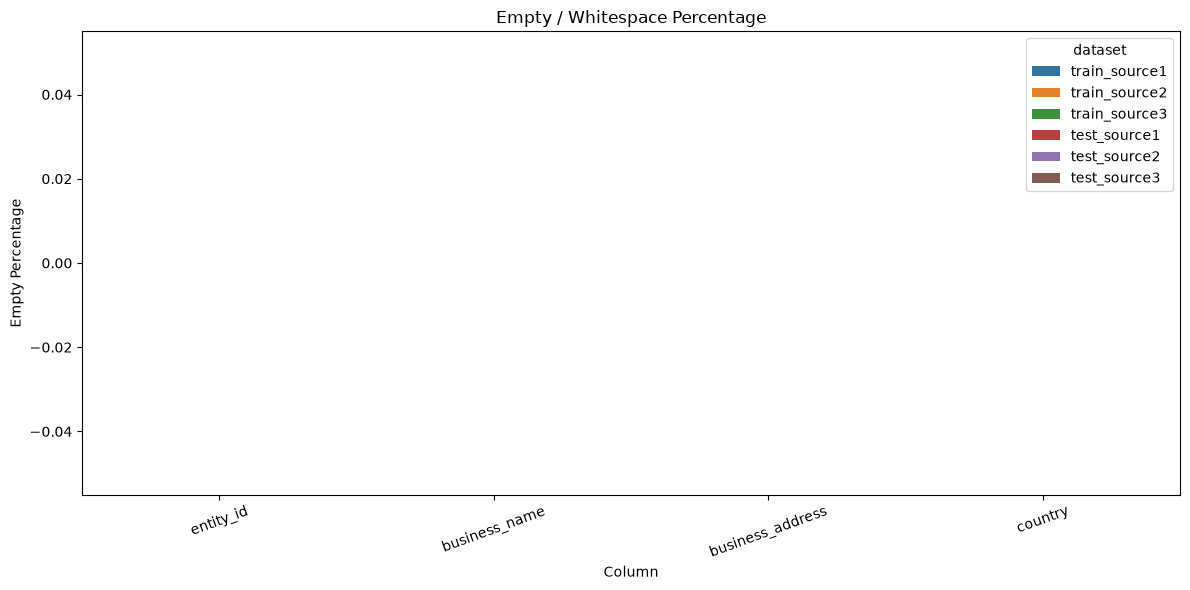

In [44]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=empty_summary_df,
    x="column",
    y="empty_percentage",
    hue="dataset"
)

plt.title("Empty / Whitespace Percentage")
plt.xlabel("Column")
plt.ylabel("Empty Percentage")

plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "empty_percentage.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

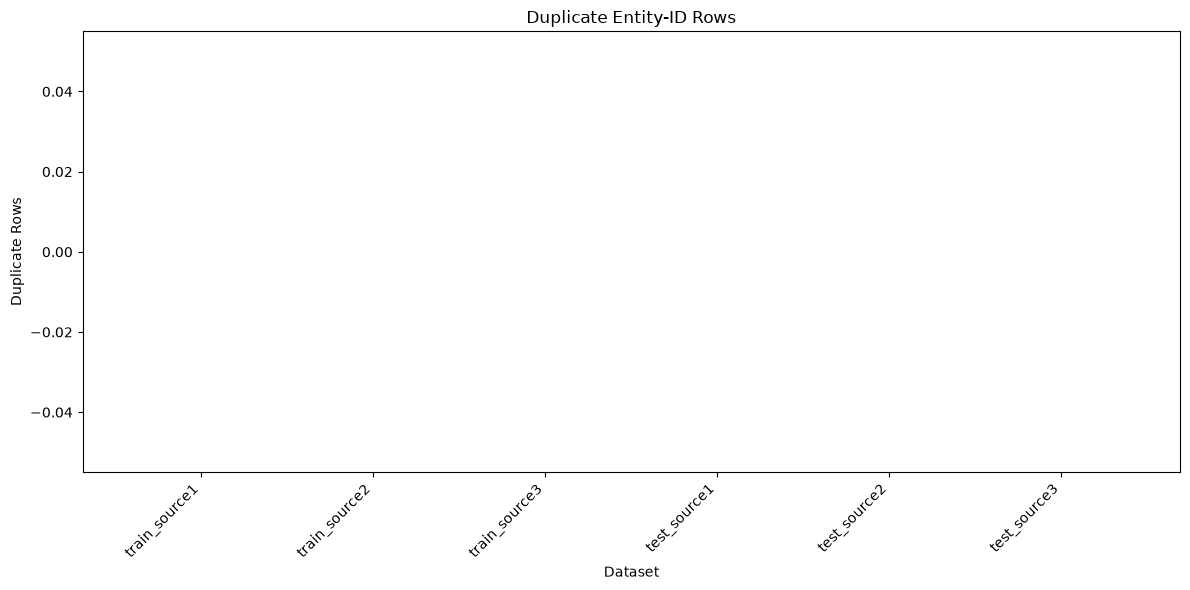

In [45]:
plt.figure(figsize=(12, 6))

plt.bar(
    entity_id_summary_df["dataset"],
    entity_id_summary_df["duplicate_entity_id_rows"]
)

plt.title("Duplicate Entity-ID Rows")
plt.xlabel("Dataset")
plt.ylabel("Duplicate Rows")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "duplicate_entity_ids.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

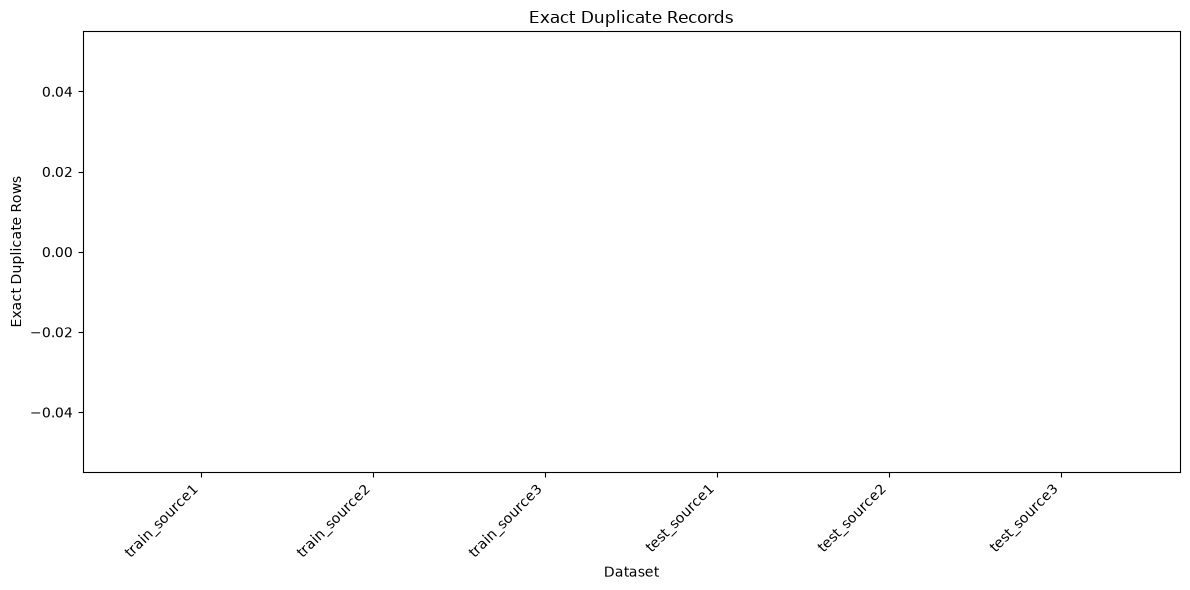

In [46]:
plt.figure(figsize=(12, 6))

plt.bar(
    exact_duplicate_df["dataset"],
    exact_duplicate_df["exact_duplicate_rows"]
)

plt.title("Exact Duplicate Records")
plt.xlabel("Dataset")
plt.ylabel("Exact Duplicate Rows")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "exact_duplicate_records.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

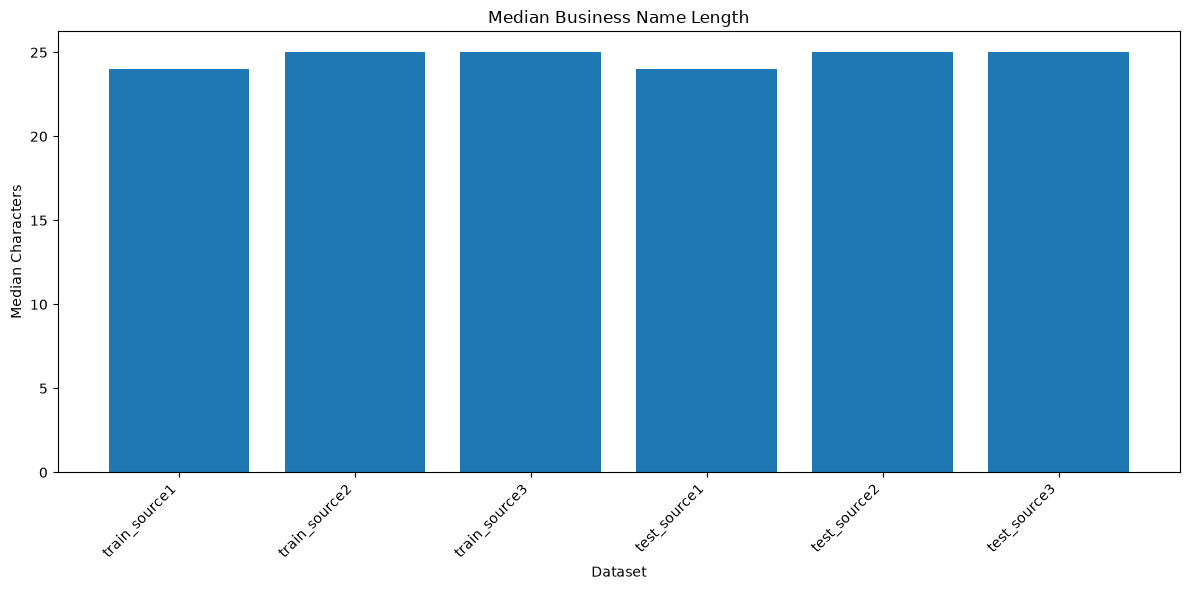

In [47]:
plt.figure(figsize=(12, 6))

plt.bar(
    name_quality_df["dataset"],
    name_quality_df["median_length"]
)

plt.title("Median Business Name Length")
plt.xlabel("Dataset")
plt.ylabel("Median Characters")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "median_business_name_length.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

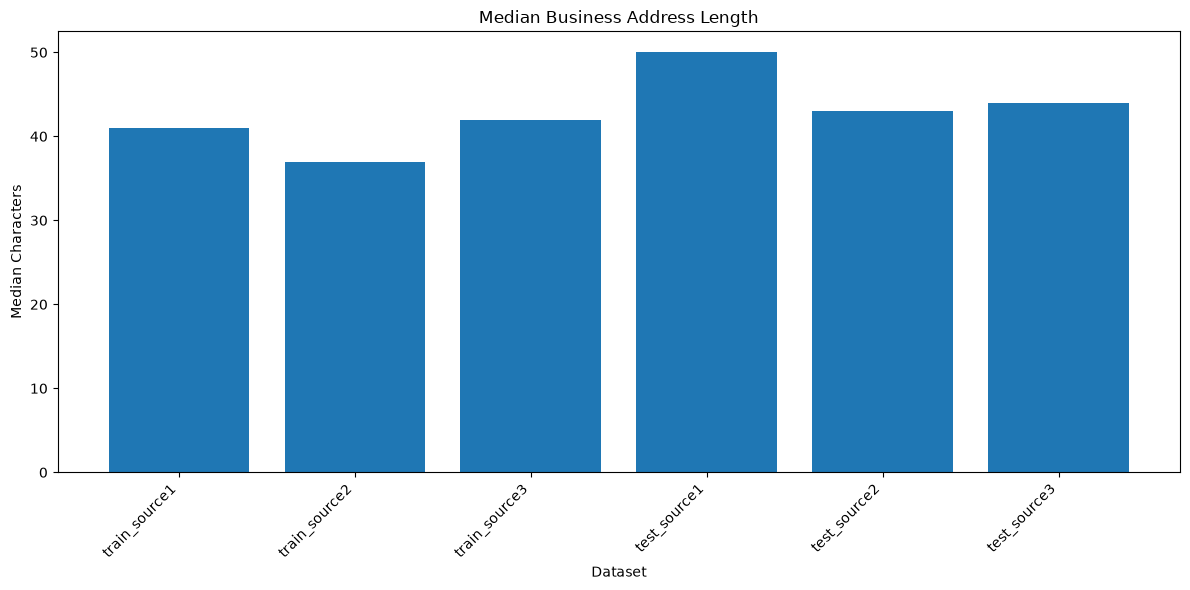

In [48]:
plt.figure(figsize=(12, 6))

plt.bar(
    address_quality_df["dataset"],
    address_quality_df["median_length"]
)

plt.title("Median Business Address Length")
plt.xlabel("Dataset")
plt.ylabel("Median Characters")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "median_business_address_length.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [49]:
tables_to_save = {
    "row_counts.csv": row_counts_df,
    "null_summary.csv": null_summary_df,
    "empty_summary.csv": empty_summary_df,
    "combined_missing_summary.csv": combined_missing_df,
    "entity_id_uniqueness.csv": entity_id_summary_df,
    "exact_duplicate_summary.csv": exact_duplicate_df,
    "business_name_quality.csv": name_quality_df,
    "business_address_quality.csv": address_quality_df,
    "country_quality.csv": country_quality_df,
    "country_distribution.csv": country_distribution_df,
    "business_name_format_quality.csv": name_format_df,
    "business_address_format_quality.csv": address_format_df,
    "cross_source_entity_id_overlap.csv": id_overlap_df,
    "ground_truth_summary.csv": ground_truth_summary_df,
    "ground_truth_quality.csv": ground_truth_quality_df,
    "ground_truth_source1_validation.csv": gt_source1_validation_df,
    "master_data_quality_summary.csv": master_quality_df,
}

for filename, df in tables_to_save.items():
    df.to_csv(
        TABLE_DIR / filename,
        index=False
    )

print(f"Saved {len(tables_to_save)} tables.")
print("Location:", TABLE_DIR.resolve())

Saved 17 tables.
Location: C:\Projects\amazon-ml-challenge-2026-main\student_resource\eda_outputs\tables


In [50]:
print("GENERATED OUTPUT FILES")
print("=" * 80)

for path in sorted(TABLE_DIR.iterdir()):
    print(path.name)

print("\nFIGURES")
print("=" * 80)

for path in sorted(FIGURE_DIR.iterdir()):
    print(path.name)

GENERATED OUTPUT FILES
business_address_format_quality.csv
business_address_quality.csv
business_name_format_quality.csv
business_name_quality.csv
combined_missing_summary.csv
country_distribution.csv
country_quality.csv
cross_source_entity_id_overlap.csv
dataset_profile.csv
empty_summary.csv
entity_id_uniqueness.csv
exact_duplicate_summary.csv
ground_truth_quality.csv
ground_truth_source1_validation.csv
ground_truth_summary.csv
master_data_quality_summary.csv
null_summary.csv
row_counts.csv
sample_empty_summary.csv
sample_entity_id_summary.csv
sample_null_summary.csv
sample_unique_summary.csv
schema_summary.csv

FIGURES
dataset_file_sizes.png
dataset_row_counts.png
duplicate_entity_ids.png
empty_percentage.png
exact_duplicate_records.png
median_business_address_length.png
median_business_name_length.png
null_percentage.png


In [51]:
print("=" * 90)
print("DATA QUALITY SUMMARY")
print("=" * 90)

print("\nROW COUNTS")
display(row_counts_df)

print("\nENTITY ID UNIQUENESS")
display(entity_id_summary_df)

print("\nMASTER QUALITY SUMMARY")
display(master_quality_df)

print("\nGROUND TRUTH SUMMARY")
display(ground_truth_summary_df)

print("\nGROUND TRUTH SOURCE1 VALIDATION")
display(gt_source1_validation_df)

DATA QUALITY SUMMARY

ROW COUNTS


,dataset,row_count
0,train_source1,2206821
1,train_source2,5034616
2,train_source3,5285603
3,train_ground_truth,2206821
4,test_source1,1732544
5,test_source2,4887273
6,test_source3,5082316



ENTITY ID UNIQUENESS


,dataset,total_rows,non_null_entity_ids,unique_entity_ids,duplicate_entity_id_rows,unique_percentage
0,train_source1,2206821,2206821,2206821,0,100.0
1,train_source2,5034616,5034616,5034616,0,100.0
2,train_source3,5285603,5285603,5285603,0,100.0
3,test_source1,1732544,1732544,1732544,0,100.0
4,test_source2,4887273,4887273,4887273,0,100.0
5,test_source3,5082316,5082316,5082316,0,100.0



MASTER QUALITY SUMMARY


,dataset,total_rows,entity_id_null_pct,entity_id_empty_pct,business_name_null_pct,business_name_empty_pct,business_address_null_pct,business_address_empty_pct,country_null_pct,country_empty_pct,duplicate_entity_id_rows,exact_duplicate_rows
0,train_source1,2206821,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,0.0,0,0
1,train_source2,5034616,0.0,0.0,0.0,0.0,3.3561,0.0,0.0,0.0,0,0
2,train_source3,5285603,0.0,0.0,0.0,0.0,3.3282,0.0,0.0,0.0,0,0
3,test_source1,1732544,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,0.0,0,0
4,test_source2,4887273,0.0,0.0,0.0,0.0,2.6479,0.0,0.0,0.0,0,0
5,test_source3,5082316,0.0,0.0,0.0,0.0,2.6779,0.0,0.0,0.0,0,0



GROUND TRUTH SUMMARY


,total_rows,non_null_source1_entity_ids,non_null_matched_entity_ids,unique_source1_entity_ids
0,2206821,2206821,2083574,2206821



GROUND TRUTH SOURCE1 VALIDATION


,ground_truth_unique_ids,ids_found_in_source1,ids_missing_from_source1
0,2206821,2206821,0


# Data Quality Findings

## 1. Dataset Size

The full training and test source datasets were analyzed using
DuckDB-based queries without loading the complete datasets into
Pandas memory.

The exact row counts are recorded in:

`eda_outputs/tables/row_counts.csv`


## 2. Missing Values

NULL values were measured independently for:

- `entity_id`
- `business_name`
- `business_address`
- `country`

Empty and whitespace-only values were analyzed separately because an
empty string is different from a SQL NULL.

The detailed results are available in:

`combined_missing_summary.csv`


## 3. Entity ID Quality

The uniqueness of `entity_id` was evaluated independently within each
source dataset.

Duplicate IDs were separately identified for inspection.

Results:

`entity_id_uniqueness.csv`


## 4. Exact Duplicate Records

Complete-record duplicates were measured using:

- entity ID
- business name
- business address
- country

Results:

`exact_duplicate_summary.csv`


## 5. Business Name Quality

Business names were analyzed for:

- NULL values
- empty values
- very short values
- average length
- median length
- maximum length
- digits
- special characters

These characteristics are relevant to the later normalization and
similarity stages.


## 6. Business Address Quality

Business addresses were analyzed for:

- NULL values
- empty values
- very short values
- average length
- median length
- maximum length
- digits
- special characters

Addresses will therefore be treated as potentially noisy textual
attributes during subsequent entity-resolution analysis.


## 7. Country Quality

Country values were analyzed for:

- missing values
- empty values
- number of distinct values
- frequency distribution

The observed representation will be used to determine whether country
normalization is necessary.


## 8. Cross-Source Entity IDs

Entity-ID overlap between source datasets was measured.

Identifier overlap by itself does not establish that two records refer to
the same real-world entity. It is therefore treated as a diagnostic
rather than as a matching rule.


## 9. Ground Truth

The ground-truth dataset was independently profiled.

The analysis includes:

- total ground-truth rows
- NULL values
- empty values
- unique source1 identifiers
- duplicate source1 identifiers
- source1 identifier existence validation

The representation of `matched_entity_ids` was inspected before applying
any delimiter-specific parsing logic.


## 10. Implications for Entity Resolution

The data-quality findings will guide the next stages:

1. text normalization
2. name normalization
3. address normalization
4. country normalization
5. candidate generation / blocking
6. similarity feature engineering
7. candidate scoring
8. threshold selection
9. validation against ground truth
10. final prediction generation

# Conclusion

`02_data_quality.ipynb` establishes the data-quality characteristics of
the complete training and test source datasets.

The notebook covers:

- full-data row counts
- NULL analysis
- empty and whitespace analysis
- entity-ID uniqueness
- duplicate entity IDs
- exact duplicate records
- business-name quality
- address quality
- country quality
- text-format characteristics
- cross-source identifier overlap
- ground-truth quality
- source1 ground-truth validation
- diagnostic visualizations

No records are modified or deleted in this notebook.

The purpose of this stage is diagnostic: understand the raw data before
performing normalization or matching.

## Next Stage

The next notebook will investigate:

`03_normalization_analysis.ipynb`

This stage will study how business names, addresses, countries, and
other relevant fields should be normalized before candidate generation
and entity matching.